## Pointing solution with PSF matched filter

In [1]:
# On some systems the linear algebra system BLAS tries to use multiple
# threads and ends up slowing the calculations down by a huge factor. 
# Here we force it to not use threads.
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")
from pypanodecoder import eventbuilder
from pypanodecoder import pedestals
from pypanodecoder import plotting
from pypanodecoder import pointing
from pypanodecoder import stars

In [3]:
# Load the PFF files for one night's observation of MGRO 2019+37 with Fern 
# into East and West image collections

mod = 252 # Fern

datadir = "/data/CTA02/fegan/PANOSETI/data/L0/"

images_E = eventbuilder.load_pff_camera_images(datadir + f'20260708/pff/obs_Palomar.start_2026-07-08T08:52:37Z.runtype_obs-test.pffd/**/*dp_ph1024.bpp_2.module_{mod}*.pff')
images_W = eventbuilder.load_pff_camera_images(datadir + f'20260708/pff/obs_Palomar.start_2026-07-08T09:07:44Z.runtype_obs-test.pffd/**/*dp_ph1024.bpp_2.module_{mod}*.pff')

print(images_E)
print(images_W)

<CameraImages events=12940 gtis=[0]>
<CameraImages events=118949 gtis=[0]>


In [4]:
# Fit a spline model to the pedestal baseline targeting one control point 
# per 600s (10 min) of observations. Use robust estimation to minimize the 
# influence of outliers from Cherenkov events. This can take some time.

# The function returns the times of the control points (shape=N), the 
# fitted pedestal baseline (shape=N,32,32) and the pedestal RMS (shape=32,32).  

tknot_E, pedspline_E, pedsigma_E = pedestals.calculate_spline_location_and_scale(images_E, loud=True)
tknot_W, pedspline_W, pedsigma_W = pedestals.calculate_spline_location_and_scale(images_W, loud=True)

2026-07-08 10:53:28   2*565s : ################################ (Converged: 1024, Time: 7.62s)
2026-07-08 11:08:36  12*609s : ################################ (Converged: 1024, Time: 79.02s)


Text(0, 0.5, 'Pedestal baseline offset')

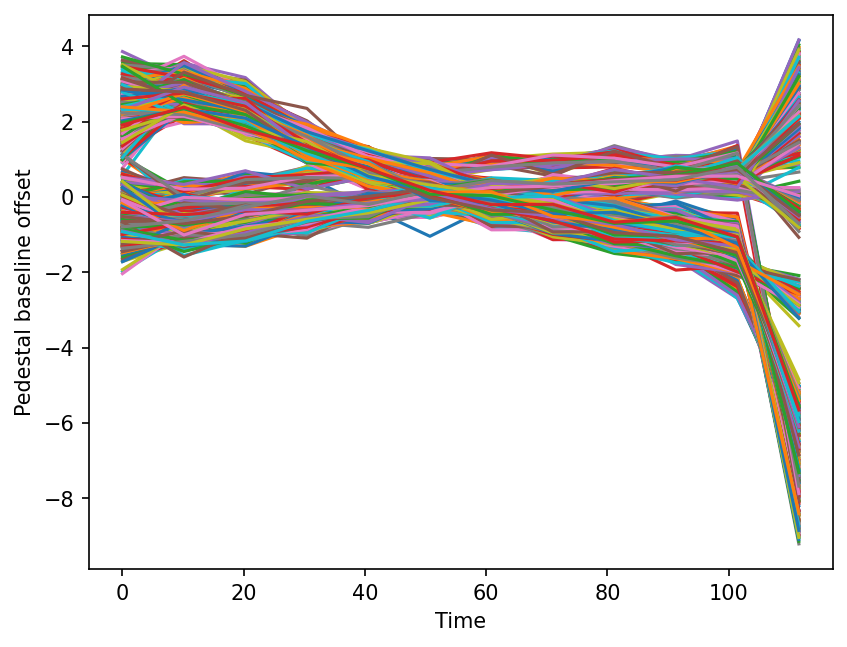

In [5]:
# Plot the spline trend (with the mean removed) for each channel as sanity check

plt.figure(dpi=150)
plt.plot(tknot_W/1e9/60, (pedspline_W - np.mean(pedspline_W,axis=-1)[:,:,None]).reshape(1024,-1).transpose());
plt.xlabel('Time')
plt.ylabel('Pedestal baseline offset')

Text(0, 0.5, 'Pedestal baseline offset')

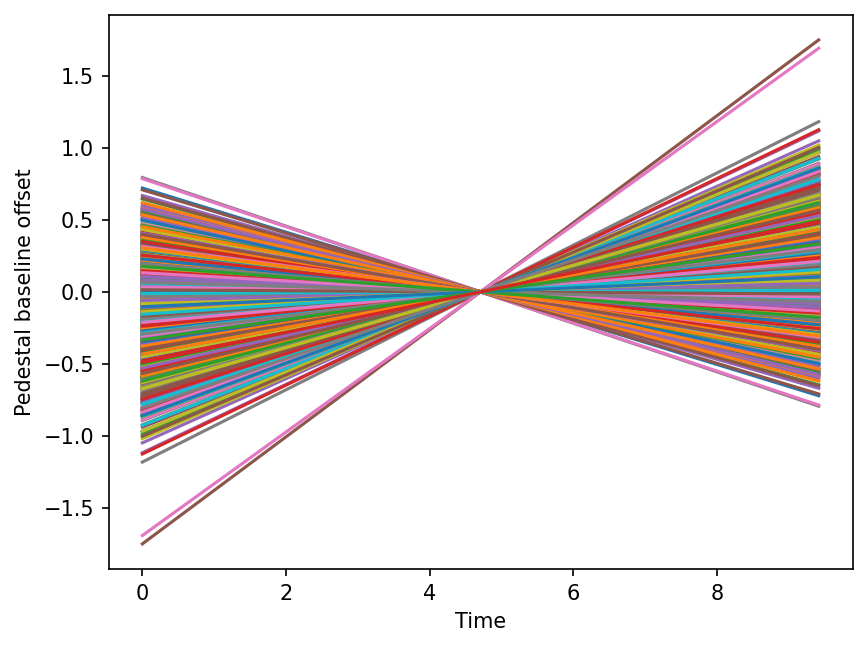

In [6]:
# And for the East...

plt.figure(dpi=150)
plt.plot(tknot_E/1e9/60, (pedspline_E - np.mean(pedspline_E,axis=-1)[:,:,None]).reshape(1024,-1).transpose());
plt.xlabel('Time')
plt.ylabel('Pedestal baseline offset')

In [ ]:
# Get the nominal coordinates for MGRO J2019+37
# Also make the wobbled coordinates for the star fit

coords = pointing.get_target_coordinates('mgroj2019+37')
coords_wobble = (coords[0], coords[1]+0.5) # Wobble !

starlist = stars.get_bright_stars(*coords, max_magnitude=5.5)

In [8]:
# Define the relative variance difference : East minus West variance
# divided by the minimum variance between the two to divide out the
# difference in gains

relvar = (pedsigma_E**2-pedsigma_W**2)/np.minimum(pedsigma_E**2,pedsigma_W**2)

Idx   HR Name           RA [deg]  Dec [deg]   Vmag    B-V  Sep [deg]    X [pix]    Y [pix]
------------------------------------------------------------------------------------------
0   7796 37Gam Cyg      305.5571    40.2567   2.20   0.68     3.4833      -2.25       9.41
1   7949 53Eps Cyg      311.5529    33.9703   2.46   1.03     6.3195     -18.55     -10.28
2   7615 21Eta Cyg      299.0767    35.0833   3.89   1.02     4.8394      14.74      -6.89
3   7834 41 Cyg         307.3487    30.3686   4.01   0.40     6.8574      -7.58     -22.53
4   7564 Chi Cyg        297.6412    32.9142   4.23   1.82     6.9600      19.07     -13.69
5   7806 39 Cyg         305.9654    32.1900   4.43   1.33     4.7820      -3.62     -16.66
6   7963 54Lam Cyg      311.8521    36.4908   4.53  -0.11     5.7896     -18.74      -2.06
7   7866 47 Cyg         308.4758    35.2508   4.61   1.60     3.4833     -10.10      -6.57
8   7763 34 Cyg         304.4467    38.0331   4.81   0.42     1.1966       0.51       2.21

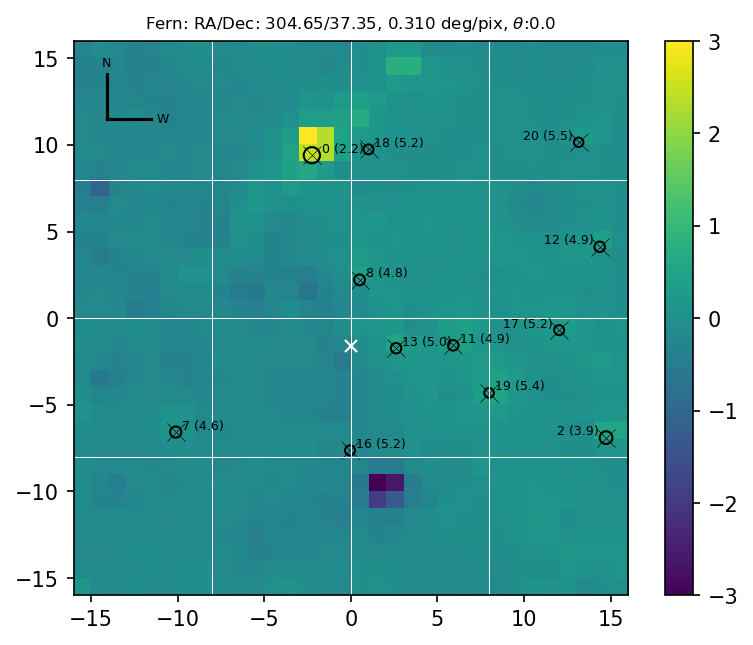

In [ ]:
# Plot the relative variance difference map and overlay the star field assuming
# a nominal pointing model (at the wobbled coordinates). It mataches pretty well!

fig = plt.figure(dpi=150)
fig, ax, ps = plotting.plot_image(relvar, fig=fig, plate_scale=1.0)

ps.set_clim(-3,3)

pnt = pointing.PointingSolution(*coords_wobble, plate_scale=0.31, theta=0)
pnt.print_stars(starlist)

plotting.overlay_stars(starlist, ax=ax, ps=pnt, clip_to_axes=True, show_mags=True, auto_align=True, use_index=True, color='k', show_cross=True, loc=2, fontsize=6)
ax.plot(*pnt.sky_to_image(*coords),'xw')
ax.set_title(f'Fern: RA/Dec: {pnt.ra0:.2f}/{pnt.dec0:.2f}, {pnt.plate_scale:.3f} deg/pix, $\\theta$:{np.rad2deg(pnt.theta):.1f}', fontsize=8);


In [11]:
# Load the PSF pack to do the matched filtering

psfpack = np.load('/data/CTA03/fegan/PANOSETI/psf_model_pack.npz')

In [12]:
# Apply the matched filter by multiplyting the variance by the PSF and summing.
# Note that the Numpy "*" operator corerctly multipies the PSF array of shape
# 257x257x32x32 by the variance array of shape 32x32 giving:
# temporary_array[y,x,j,i] = psf[y,x,j,i] * relvar[j,i] for all x,y,i,j
# Then we sum over the final two axes to give:
# filtered_var[y,x] = Sum_{j,i} psf[y,x,j,i] * relvar[j,i] for all x,y

filtered_var = (psfpack['psf'] * relvar).sum(axis=(-2, -1))

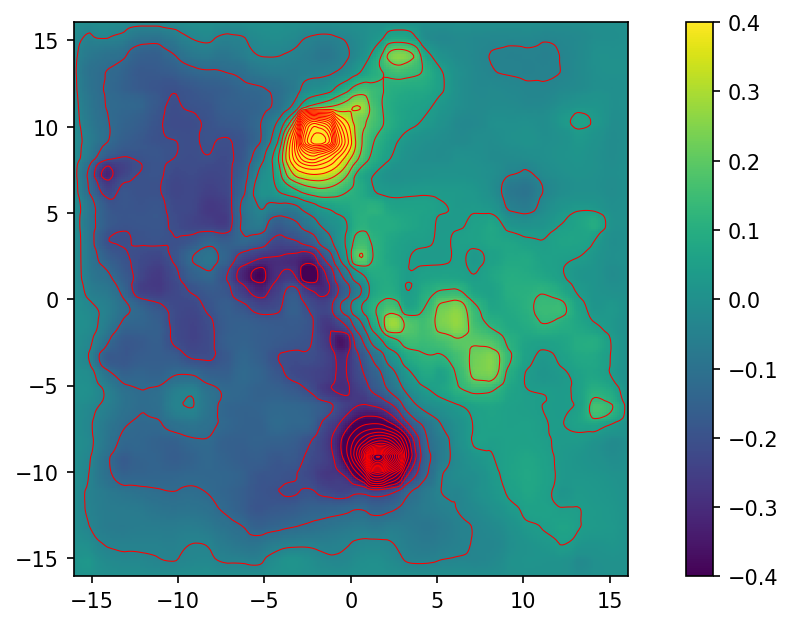

In [13]:
# Draw the matched filter map and contours

fig = plt.figure(dpi=150)
plt.pcolormesh(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var)
plt.colorbar()
plt.clim([-0.4,0.4])
plt.contour(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var, levels=np.linspace(-2,2,50), colors='r', linewidths=0.5, linestyles='-')
plt.axis('square');

<PointingSolution RA0=304.6460 Dec0=37.3470 scale=0.310000 deg/pix theta=0.00deg east_on_left=True>

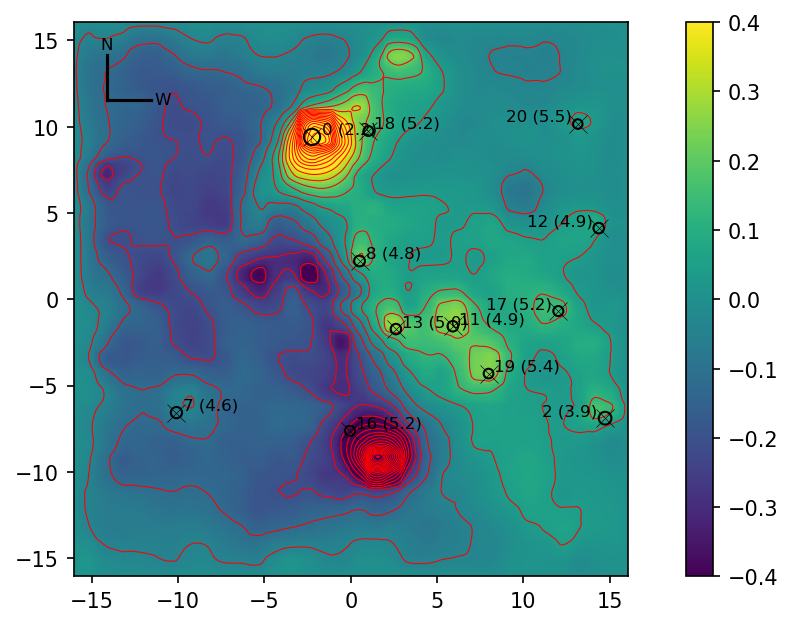

In [15]:
# Draw the matched filter map and contours and overlay the star map

fig = plt.figure(dpi=150)
plt.pcolormesh(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var)
plt.colorbar()
plt.clim([-0.4,0.4])
plt.contour(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var, levels=np.linspace(-2,2,50), colors='r', linewidths=0.5, linestyles='-')
plt.axis('square');

pnt = pointing.PointingSolution(*coords_wobble, plate_scale=0.31, theta=0)
plotting.overlay_stars(starlist, ax=plt.gca(), color='k',ps=pnt, clip_to_axes=True, show_mags=True, auto_align=True, show_cross=True, loc=2, fontsize=8, zorder=2, use_index=True)


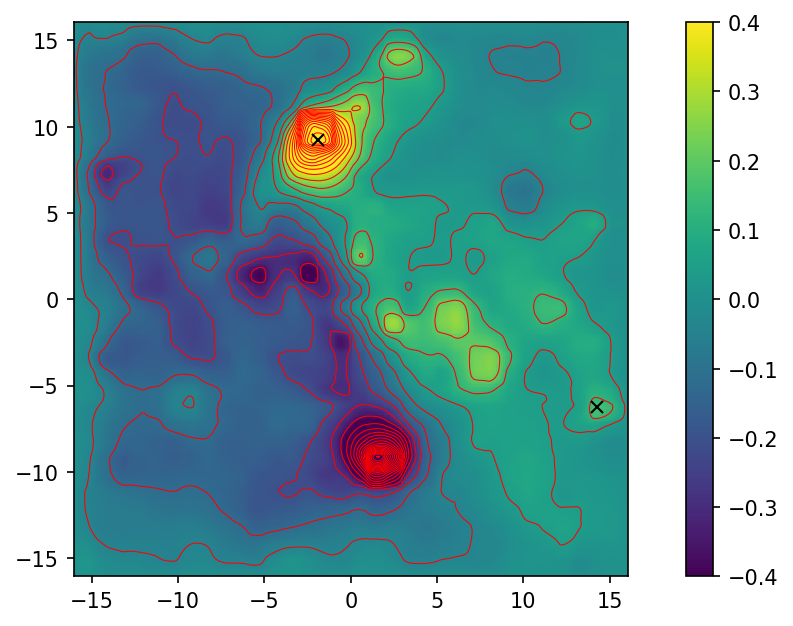

In [16]:
# Here we pick two stars and use an up-hill walking algorithm to find
# their highest point on the matched filter map. Here we use star 0 and 2
# (gam-Cyg and eta-Cyg). Perhaps eta-Cyg is too close to the edge, we might
# be better with one of the others.

fig = plt.figure(dpi=150)
plt.pcolormesh(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var)
plt.colorbar()
plt.clim([-0.4,0.4])
plt.contour(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var, levels=np.linspace(-2,2,50), colors='r', linewidths=0.5, linestyles='-')
plt.axis('square');


sloc0 = pointing.walk_uphill(*pnt.sky_to_image(starlist[0]['ra_deg'],starlist[0]['dec_deg']), filtered_var, 
                     psfpack['xgrid'], psfpack['ygrid'])
plt.plot(sloc0[0],sloc0[1],'xk')
sloc1 = pointing.walk_uphill(*pnt.sky_to_image(starlist[2]['ra_deg'],starlist[2]['dec_deg']), filtered_var, 
                     psfpack['xgrid'], psfpack['ygrid'])
plt.plot(sloc1[0],sloc1[1],'xk')

Image coordinates of MGRO J2019+37: 0.252, -1.222


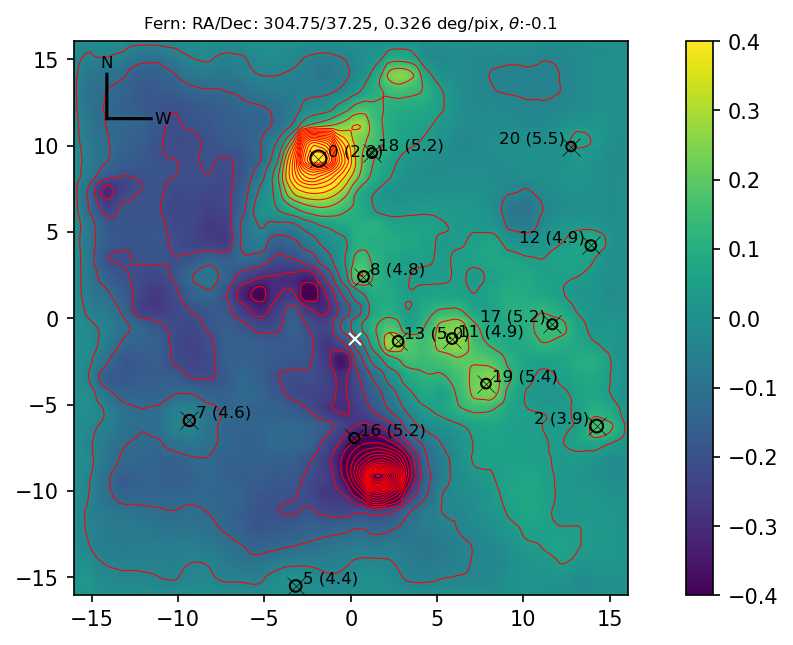

In [34]:
# Solve for a pointing model that gives the two stars in their measured
# positions and overlay the full star field. 
# Plot the position of MGRO J2019+37

fig = plt.figure(dpi=150)
plt.pcolormesh(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var)
plt.colorbar()
plt.clim([-0.4,0.4])
plt.contour(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var, levels=np.linspace(-2,2,50), colors='r', linewidths=0.5, linestyles='-')
plt.axis('square');

pnt = pointing.PointingSolution.solve(starlist[0],sloc0[:2], starlist[2],sloc1[:2])
plotting.overlay_stars(starlist, ax=plt.gca(), color='k',ps=pnt, clip_to_axes=True, show_mags=True, auto_align=True, show_cross=True, loc=2, fontsize=8, zorder=2, use_index=True)
fig.gca().plot(*pnt.sky_to_image(*coords),'xw')
print("Image coordinates of MGRO J2019+37:", ', '.join([f'{x:.3f}' for x in pnt.sky_to_image(*coords)]))

fig.gca().set_title(f'Fern: RA/Dec: {pnt.ra0:.2f}/{pnt.dec0:.2f}, {pnt.plate_scale:.3f} deg/pix, $\\theta$:{np.rad2deg(pnt.theta):.1f}', fontsize=8);

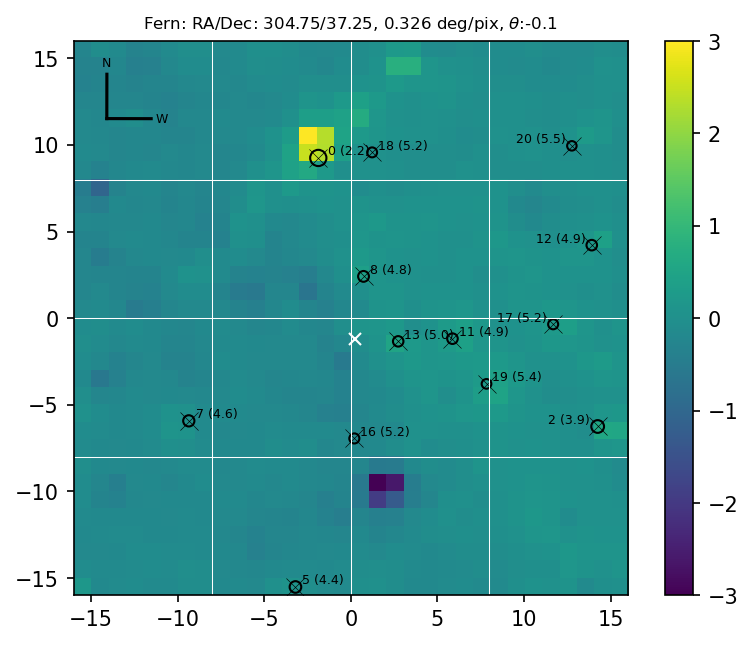

In [33]:
# Plot the model over the unfiltered relative variance difference map.

# Note that the PSF pack is parameterised by intersection of the principal ray
# and the image plane (in a thin lens assumption), assunming a usual projection
# of the direction of the rays on the focal plane. But this does not well
# represent the distribution of the ray intersections with the focal plane,
# as evidenced by the fact that the star positions seem to be offset from the
# excesses. One might prefer to represent the star positions by the "mean",
# the "median", or the center of the smallest 50% containment circle. See below.

fig = plt.figure(dpi=150)
fig, ax, ps = plotting.plot_image(relvar, fig=fig, plate_scale=1.0)

ps.set_clim(-3,3)

plotting.overlay_stars(starlist, ax=ax, ps=pnt, clip_to_axes=True, show_mags=True, auto_align=True, use_index=True, color='k', show_cross=True, loc=2, fontsize=6)
ax.plot(*pnt.sky_to_image(*coords),'xw')
ax.set_title(f'Fern: RA/Dec: {pnt.ra0:.2f}/{pnt.dec0:.2f}, {pnt.plate_scale:.3f} deg/pix, $\\theta$:{np.rad2deg(pnt.theta):.1f}', fontsize=8);


Image coordinates of MGRO J2019+37: 0.371, -1.266


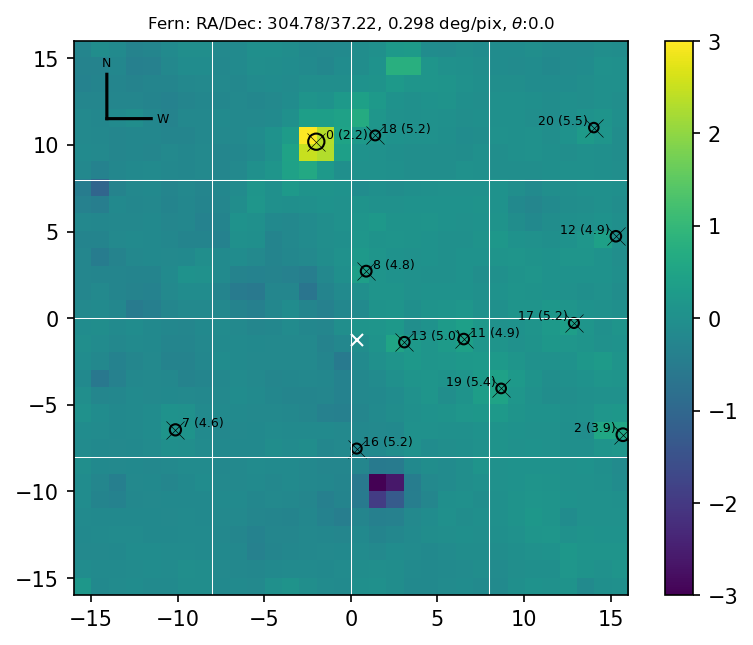

In [36]:
# The PSF pack also stores the median, mean and 50% containment circle for the
# rays. Here we use the fitted position of the two stars from the up-hill walk,
# given by the final two entries in the "sloc0" and "sloc1" tuples as indexes into
# the "xmedian" and "ymedian" arrays in the PSF pack to find the medians of the
# light distribution. Note we must reverse the indexes from i,j -> j,i for use
# in then median arrays

# We then refit a model using these median positions and overlay the stars on the
# unfiltered variance map. The stars align better with the excesses. The major 
# difference is in the fitted plate scale of 0.298 deg/pixel here vs 0.326 above.
# The position of MGRO on the image plane remains largely the same, as the target 
# is close to the center of the FoV where the aberations are small.

# Note: this is not necessily a better model, it's just a reparametrisation. Which
# one is more appropiate? It depends on how the PSF effects are to be corrected for
# when calculating the Hillas parameters. Do we simply adjust the plate scale to
# account for the effects of the PSF? Try to fix to a higher order (twisting etc)?

sloc0_ji = sloc0[-1:-3:-1]
sloc1_ji = sloc1[-1:-3:-1]

sloc0_median = (psfpack['xmedian'][*sloc0_ji],psfpack['ymedian'][*sloc0_ji])
sloc1_median = (psfpack['xmedian'][*sloc1_ji],psfpack['ymedian'][*sloc1_ji])

pnt_median = pointing.PointingSolution.solve(starlist[0],sloc0_median, starlist[2],sloc1_median)
print("Image coordinates of MGRO J2019+37:", ', '.join([f'{x:.3f}' for x in pnt_median.sky_to_image(*coords)]))

fig = plt.figure(dpi=150)
fig, ax, ps = plotting.plot_image(relvar, fig=fig, plate_scale=1.0)

ps.set_clim(-3,3)

plotting.overlay_stars(starlist, ax=ax, ps=pnt_median, clip_to_axes=True, show_mags=True, auto_align=True, use_index=True, color='k', show_cross=True, loc=2, fontsize=6)
ax.plot(*pnt_median.sky_to_image(*coords),'xw')
ax.set_title(f'Fern: RA/Dec: {pnt_median.ra0:.2f}/{pnt_median.dec0:.2f}, {pnt_median.plate_scale:.3f} deg/pix, $\\theta$:{np.rad2deg(pnt_median.theta):.1f}', fontsize=8);
